# FASC: Python Quick-Start Tutorial

Welcome to the Python implementation of **Flexible Adaptive Stable Clustering (FASC)**. 

This notebook demonstrates how to:
1. Load a mass spectrometry dataset (`dataMatrix.csv`).
2. Configure the FASC hyperparameters (including the Dual-Cosine metric).
3. Run the core algorithm.
4. Visualize the convergence and cluster distribution.
5. Demonstrate Metric Agnosticism (Flexibility) by swapping similarity kernels.

*Note: Ensure that `fasc_core.py` is in the same directory as this notebook, and `dataMatrix.csv` is located in the `../data/` folder.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# Import the core FASC algorithm
from fasc_core import run_fasc

### 1. Load the Dataset
For this tutorial, we use `dataMatrix.csv`. In a real-world scenario with millions of spectra, you would typically load this as a `scipy.sparse` matrix to save memory. FASC natively supports both dense NumPy arrays and sparse SciPy matrices.

In [2]:
data_path = './FASC_pythonVersion/dataMatrix.csv'

print(f"Loading dataset from {data_path}...")
if os.path.exists(data_path):
    # Load CSV into a dense numpy array
    data_matrix = np.loadtxt(data_path, delimiter=',')
    print(f"Data loaded successfully! Shape: {data_matrix.shape} (Spectra x Features)")
else:
    print(f"Error: {data_path} not found. Please ensure the data folder is populated.")
    # Generate dummy data for demonstration if file is missing
    print("Generating dummy data for demonstration...")
    data_matrix = np.random.rand(1000, 600)
    data_matrix[data_matrix < 0.8] = 0 # Make it sparse-like

Loading dataset from ./FASC_pythonVersion/dataMatrix.csv...
Data loaded successfully! Shape: (10000, 600) (Spectra x Features)


### 2. Configure FASC Parameters
Here we define the indices for the positive and negative ion modes required by the `dual-cosine` metric, along with the structural thresholds $\tau_{intra}$ and $\tau_{inter}$.

In [3]:
# Define feature indices for Dual-Cosine metric
# Assuming 600 features: 0-299 are positive ion mode, 300-599 are negative ion mode
idx_pos = np.arange(0, 300)
idx_neg = np.arange(300, 600)

# FASC Hyperparameters
sim_inter  = 0.70      # Merge threshold (Inter-cluster separation)
sim_intra  = 0.70      # Assignment threshold (Intra-cluster compactness)
init_limit = 10        # Initial seeds per iteration
max_clust  = 50        # Maximum capacity budget (K_max)
max_iter   = 100       # Maximum iterations before forced stop
min_vol    = 3         # Minimum particles required to form a valid cluster
strategy   = 'DASS'    # Density-Augmented Similarity Selection
algo       = 'dual-cosine'  # Similarity metric

### 3. Run the FASC Algorithm
The algorithm will print its progress, including the outlier count and inter-iteration similarity, until it reaches a deterministic fixed-point or limit cycle.

In [4]:

print("Starting FASC clustering...")
centers, counts, labels, iter_data, total_iters = run_fasc(
    data_matrix=data_matrix, 
    idx_pos=idx_pos, 
    idx_neg=idx_neg, 
    sim_inter=sim_inter, 
    sim_inner=sim_intra, 
    init_limit=init_limit, 
    max_clusters=max_clust, 
    max_iter=max_iter, 
    strategy=strategy, 
    min_vol=min_vol, 
    algo=algo
)

Starting FASC clustering...
========= FASC Start =========
Pre-normalizing data for 'dual-cosine' metric...
Iteration 1 start
	Outlier count: 3434
	Completed in 0.29s
	Inter-iteration similarity: 0.00000%
Iteration 2 start
	Outlier count: 3598
	Completed in 0.06s
	Inter-iteration similarity: 75.61439%
Iteration 3 start
	Outlier count: 2094
	Completed in 0.06s
	Inter-iteration similarity: 89.50019%
Iteration 4 start
	Outlier count: 1841
	Completed in 0.06s
	Inter-iteration similarity: 89.08555%
Iteration 5 start
	Outlier count: 1754
	Completed in 0.07s
	Inter-iteration similarity: 94.51067%
Iteration 6 start
	Outlier count: 1573
	Completed in 0.06s
	Inter-iteration similarity: 92.95313%
Iteration 7 start
	Outlier count: 1496
	Completed in 0.06s
	Inter-iteration similarity: 96.69333%
Iteration 8 start
	Outlier count: 1432
	Completed in 0.07s
	Inter-iteration similarity: 96.29212%
Iteration 9 start
	Outlier count: 1473
	Completed in 0.07s
	Inter-iteration similarity: 97.23663%
Iteration 1

### 4. Analyze and Visualize Results
Once converged, we can inspect the cluster size distribution and the convergence history to verify algorithmic stability.


FASC CLUSTERING SUMMARY
Total Clusters Found: 8
Total Outliers:       3434 (34.3% of data)
Clustered Spectra:    6566


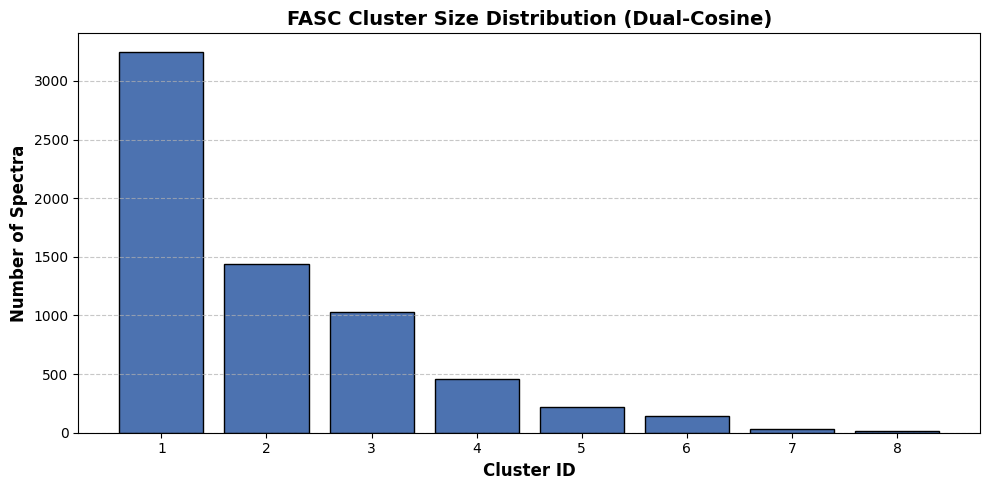

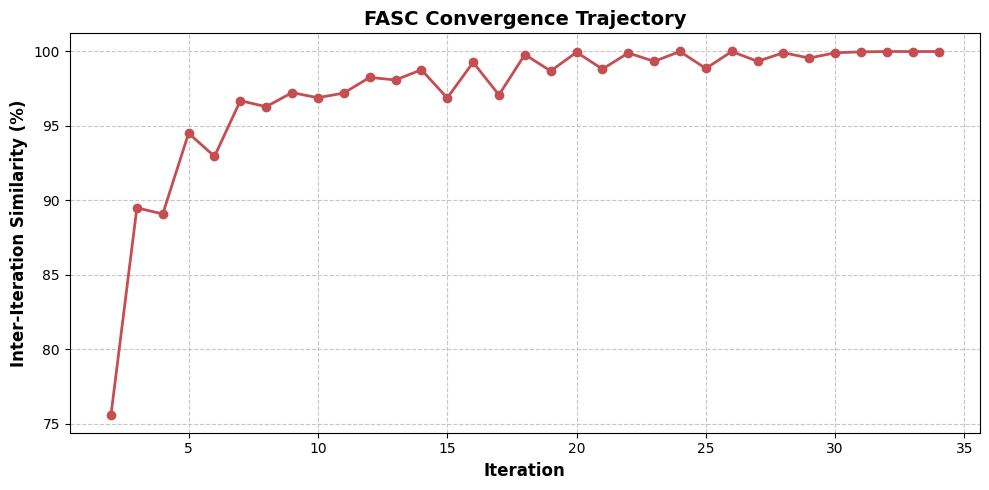

In [5]:
# 1. Print Summary Statistics
num_clusters = len(counts)
num_outliers = np.sum(labels == -1)
total_spectra = len(labels)

print("\n" + "="*40)
print("FASC CLUSTERING SUMMARY")
print("="*40)
print(f"Total Clusters Found: {num_clusters}")
print(f"Total Outliers:       {num_outliers} ({num_outliers/total_spectra*100:.1f}% of data)")
print(f"Clustered Spectra:    {total_spectra - num_outliers}")
print("="*40)

# 2. Plot Cluster Size Distribution
plt.figure(figsize=(10, 5))
plt.bar(range(1, num_clusters + 1), counts, color='#4C72B0', edgecolor='black')
plt.xlabel('Cluster ID', fontsize=12, fontweight='bold')
plt.ylabel('Number of Spectra', fontsize=12, fontweight='bold')
plt.title('FASC Cluster Size Distribution (Dual-Cosine)', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Plot Convergence History (Inter-iteration similarity)
valid_iters = iter_data[:total_iters, 0]

plt.figure(figsize=(10, 5))
plt.plot(range(2, total_iters + 1), valid_iters[1:] * 100, marker='o', color='#C44E52', linewidth=2, markersize=6)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Inter-Iteration Similarity (%)', fontsize=12, fontweight='bold')
plt.title('FASC Convergence Trajectory', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5. Demonstrating Metric Agnosticism (Flexibility)
Unlike traditional clustering algorithms that are mathematically bound to specific distances (e.g., K-Means strictly requires Euclidean distance), FASC decouples similarity evaluation from the core optimization logic. 

This means you can swap in almost any bounded symmetric similarity metric simply by changing the `algo` parameter, without breaking the solver. Here, we demonstrate running FASC on the exact same data using **Standard Cosine Similarity** and **L1 (Manhattan) Similarity**. 

In [6]:
print("\n--- Running FASC with Standard Cosine Metric ---")
centers_cos, counts_cos, labels_cos, _, _ = run_fasc(
    data_matrix=data_matrix, 
    idx_pos=None, idx_neg=None,  # Not needed for standard metrics
    sim_inter=0.85, sim_inner=0.85, # Adjusted thresholds for standard cosine
    init_limit=init_limit, max_clusters=max_clust, max_iter=50, 
    strategy=strategy, min_vol=min_vol, algo='cosine'
)
print(f"\nStandard Cosine identified {len(counts_cos)} clusters and {np.sum(labels_cos == -1)} outliers.")

print("\n--- Running FASC with L1 (Manhattan) Metric ---")
centers_l1, counts_l1, labels_l1, _, _ = run_fasc(
    data_matrix=data_matrix, 
    idx_pos=None, idx_neg=None, 
    sim_inter=0.85, sim_inner=0.85, 
    init_limit=init_limit, max_clusters=max_clust, max_iter=50, 
    strategy=strategy, min_vol=min_vol, algo='l1'
)
print(f"\nL1 (Manhattan) identified {len(counts_l1)} clusters and {np.sum(labels_l1 == -1)} outliers.")


--- Running FASC with Standard Cosine Metric ---
========= FASC Start =========
Pre-normalizing data for 'cosine' metric...
Iteration 1 start
	Outlier count: 3375
	Completed in 0.16s
	Inter-iteration similarity: 0.00000%
Iteration 2 start
	Outlier count: 3180
	Completed in 0.04s
	Inter-iteration similarity: 85.68008%
Iteration 3 start
	Outlier count: 2119
	Completed in 0.04s
	Inter-iteration similarity: 95.60312%
Iteration 4 start
	Outlier count: 1933
	Completed in 0.04s
	Inter-iteration similarity: 94.06090%
Iteration 5 start
	Outlier count: 1930
	Completed in 0.04s
	Inter-iteration similarity: 96.37215%
Iteration 6 start
	Outlier count: 1661
	Completed in 0.04s
	Inter-iteration similarity: 97.05966%
Iteration 7 start
	Outlier count: 1820
	Completed in 0.04s
	Inter-iteration similarity: 97.78210%
Iteration 8 start
	Outlier count: 1735
	Completed in 0.05s
	Inter-iteration similarity: 98.13007%
Iteration 9 start
	Outlier count: 1677
	Completed in 0.04s
	Inter-iteration similarity: 98.3